### Importing Libraries

In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

## About Dataset

- This is a retail sales data of year 2023 and 2024, which contains wide range of information about sales, transactions, products and customers all combined in a single csv file.
- Total number of records in the dataset is 302010 and number of columns are 30.

## Problem Statement

**Project Title:** Multi-Category Retail Demand and Sales Forecasting Engine

---

**1. Executive Summary & Business Context :**
Modern retail operations face high holding costs from over-stocking and lost revenue due to stockouts. The objective of this project is to convert raw transactional event logs into a continuous time-series regression pipeline that accurately forecasts daily unit demand across product categories. This enables procurement and inventory teams to optimize replenishment schedules, reduce working capital waste, and maintain optimal service levels.

---

**2. Problem Formulation**

* **ML Task:** Supervised Multi-Horizon Time-Series Regression.

* **Unit of Analysis (Granularity):** Daily demand per product category ($\text{Date} \times \text{Product Category}$).

* **Target Variable ($y$):** $y_{c, t} =$ Total units demanded for product category $c$ on calendar day $t$ (derived from aggregating the transaction quantities).

* **Objective Function:** Minimize forecast deviation across out-of-time evaluation windows:


$$\hat{y}_{c, t} = f\left(\mathbf{X}_{\text{lags}}, \mathbf{X}_{\text{rolling}}, \mathbf{X}_{\text{calendar}}, \mathbf{X}_{\text{category}}\right)$$

---

**3. Data Pipeline & Preprocessing Requirements**

* **PII & Identifier Removal:** Drop non-predictive columns including `transaction ID`, `customer ID`, `name`, `email`, `phone`, `address`, and `zip code` to prevent model overfitting.


* **Target Leakage Elimination:** Exclude post-purchase attributes (`order status`, `feedback`, `ratings`, `shipping method`, `payment method`) that are unavailable at inference time.


* **Time-Series Aggregation & Resampling:** Resample irregular transaction events into uniform daily buckets $\left(\sum \text{total purchases}\right)$ grouped by `date` and `product category`.


---

**4. Feature Engineering Scope**

* **Lag Features:** Prior demand signals at intervals $t-1$, $t-7$, and $t-14$ to capture autoregressive properties and weekly demand cycles.

* **Rolling Window Statistics:** 7-day and 14-day rolling means and standard deviations to capture medium-term demand velocity and volatility.

* **Temporal / Calendar Features:** `day_of_week`, `month`, `quarter`, and binary indicators for `is_weekend`.

* **Categorical Encoding:** One-Hot Encoding for categorical segment identifiers (`product category`) within an isolated preprocessing pipeline.

---

**5. Validation Strategy & Evaluation Metrics**

* **Split Strategy:** Strict chronological/temporal split (e.g., historical 80% training window, trailing 20% holdout test window) to prevent temporal data leakage.

* **Primary Evaluation Metrics:**

* **Mean Absolute Error (MAE):** Quantifies average unit-level deviation.

* **Root Mean Squared Error (RMSE):** Penalizes large outlier forecasting errors.

* **Weighted Absolute Percentage Error (WAPE):** Provides scale-independent percentage accuracy across varying category volumes.

* **Baseline Benchmark:** Performance must be compared against a naïve baseline (e.g., historical moving average or previous-week lag $t-7$).

#### Import CSV Data as Pandas DataFrame

In [ ]:
df = pd.read_csv('../data/raw/sales_data.csv')

#### Show top 5 records

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


#### Shape of dataset

In [ ]:
df.shape

(302010, 30)

#### All columns of dataset

In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address',
       'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income',
       'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases',
       'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand',
       'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method',
       'Order_Status', 'Ratings', 'products'],
      dtype='str')

## 3. Data Checks to perform

- Check duplicates
- Check datatypes
- Check missing values
- Check the number of unique values in each column
- Check statistics of dataset
- Check various categories present in the different categorical column

### 3.1 Check missing values

In [ ]:
df.isna().sum()

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64

Except `'products'` and `'Product_Type'` all columns have null values ranging from 173 null values in `'Age'` to 382 null values in `'Name'`.

### 3.2 Check duplicates

In [ ]:
df.duplicated().sum()

np.int64(4)

There are 4 duplicate records in the dataset.

### 3.3 Check data types

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  str    
 3   Email             301663 non-null  str    
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  str    
 6   City              301762 non-null  str    
 7   State             301729 non-null  str    
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  str    
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  str    
 12  Income            301720 non-null  str    
 13  Customer_Segment  301795 non-null  str    
 14  Date              301651 non-null  str    
 15  Year              301660 non-null  float64
 16  Month             301737 non-nu

Datatypes need to be fixed as downcasting needed to properly allocte dtypes to different types of columns

### 3.4 Check unique values in each columns

In [ ]:
df.nunique()

Transaction_ID      294461
Customer_ID          86766
Name                159390
Email                52897
Phone               299295
Address             299329
City                   130
State                   54
Zipcode              93978
Country                  5
Age                     53
Gender                   2
Income                   3
Customer_Segment         3
Date                   366
Year                     2
Month                   12
Time                 83677
Total_Purchases         10
Amount              299297
Total_Amount        299305
Product_Category         5
Product_Brand           18
Product_Type            33
Feedback                 4
Shipping_Method          3
Payment_Method           4
Order_Status             4
Ratings                  5
products               318
dtype: int64

#### Need to revisit this later

### 3.5 Check statistics of dataset

In [ ]:
df.describe()

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,3.016770e+05,301702.000000,3.016480e+05,301670.000000,301837.000000,301660.000000,301649.000000,301653.000000,301660.000000,301826.000000
mean,5.495823e+06,55006.553934,5.501464e+09,50298.951019,35.481326,2023.165113,5.359729,255.163659,1367.651156,3.162670
std,2.595565e+06,26005.675200,2.596017e+09,28972.807134,15.021933,0.371283,2.868575,141.389640,1128.998515,1.320827
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247930e+06,32469.250000,3.255061e+09,25425.000000,22.000000,2023.000000,3.000000,132.890764,438.724278,2.000000
50%,5.499657e+06,55012.000000,5.505812e+09,50602.500000,32.000000,2023.000000,5.000000,255.470969,1041.117547,3.000000
75%,7.739509e+06,77511.000000,7.749860e+09,75252.000000,46.000000,2023.000000,8.000000,377.672606,2029.999853,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024.000000,10.000000,499.997911,4999.625796,5.000000


#### Insight

- Almost all the records have ratings and mean ratings is 3.16.
- quantity purchased from 1 to 10.
- amount of product ranges from 10 to 500 with 255.16 mean amount
- total amount of products ranges from 10 to 5000 whereas mean total amount is 1367
- more than 75% of the records is from 2023 year, mean year is 2023.16
- age of customers ranging from 18 to 70 whereas mean age is 35.5

### 3.6 Exploring Data

In [ ]:
print("Categories in 'Country' variable :    ", end = " ")
print(df['Country'].unique())
print()

print("Categories in 'State' variable :    ", end = " ")
print(df['State'].unique())
print()

print("Categories in 'Age' variable :    ", end = " ")
print(df['Age'].unique())
print()

print("Categories in 'Gender' variable :    ", end = " ")
print(df['Gender'].unique())
print()

print("Categories in 'Income' variable :    ", end = " ")
print(df['Income'].unique())
print()

print("Categories in 'Customer Segment' variable :    ", end = " ")
print(df['Customer_Segment'].unique())
print()

print("Categories in 'Shipping Method' variable :    ", end = " ")
print(df['Shipping_Method'].unique())
print()

print("Categories in 'Payment Method' variable :    ", end = " ")
print(df['Payment_Method'].unique())
print()

print("Categories in 'Order Status' variable :    ", end = " ")
print(df['Order_Status'].unique())
print()


Categories in 'Country' variable :     <StringArray>
['Germany', 'UK', 'Australia', 'Canada', 'USA', nan]
Length: 6, dtype: str

Categories in 'State' variable :     <StringArray>
[         'Berlin',         'England', 'New South Wales',         'Ontario',
        'Virginia',          'Nevada',        'Colorado',        'Arkansas',
           'Texas',        'Oklahoma',     'Connecticut',     'Mississippi',
               nan,       'Wisconsin',          'Oregon',        'Michigan',
          'Alaska',      'New Jersey',         'Wyoming',           'Maine',
           'Idaho',         'Alabama',   'New Hampshire',       'Minnesota',
        'Delaware',  'South Carolina',        'Nebraska',      'New Mexico',
         'Arizona',         'Indiana',            'Iowa',        'Illinois',
            'Ohio',         'Georgia',        'New York',    'Pennsylvania',
   'Massachusetts',    'Rhode Island',         'Montana',        'Missouri',
   'West Virginia',       'Louisiana',          'K

### Key Points

- No similarities found between name and email id.
- 4 duplicate records exist.
- out of 302010 records, 294461 record's transactions are unique and non null.
- No of unique customer_id : 86766
- No of unique name of customers : 159390.

***Customer Information***
- `'customer_id'` : It is a unique identifier of customer data, no two different customer can have same `customer_id`. 
- `'name'` : It represents name of the person placing order, it might be possible that single `customer_id` linked with more than one name `name`.
- `'email'` : It represents email id of the customer or the person making order.
- `'phone'` : It is the contact number of the person. it can also be classified as unique identifier.
- `'age'` : It is the age of the user. widely varies from 18 years to 70 years.
- `'gender'` : customers genders are male and female only.
- `'income'` : customers are grouped into categories based on their income as low, medium, and high.
- `'address'` : it represents delivery addresses of the users.
- `'city'` : city of user placing order for.
- `'state'` : state of user placing order for.
- `'zipcode'` : zipcode of location user placing order for.
- `'country'` : country of user placing order in. 
- `'customer_segment'` : customers categorised as regular, premium and new.

***Transaction Details***
- `'transaction_id'` : it represents transactions and its unique identifier. around 333 records shows NA in transaction_id. 
- `'total_purchases'` : it is the quantity of items ordering of. better to rename as quantity.
- `'total_amount'` : it is the total amount, price x quantity. 
- `'feedback'` : customer review on the product. 
- `'shipping_method'` : same day shipping, one day delivery, express delivery. 
- `'payment_method'` : debit, credit, cash.
- `'order_status'` : pending, shipped, processing, delivered.

***Product Information***
- `'products'` : name of product.
- `'amount'` : amount represents price of the product.
- `'product_category'` : category of product.
- `'product_brand'` : brand of product.
- `'product_type'` : type of product.
- `'ratings'` : how much product liked or disliked by any customer.

***Temporal Information***
- `'year'` : year of order placed
- `'month'` : month of order placed
- `'date'` : date of order placed, better to transform it into day of month.
- `'time'` : time of order placed.

### Problems Found 
- Transaction_id and customer_id dtype need to change in integer from float.
- remove duplicate records.

***Potential Analysis***
- Customer segmentation analysis based on demographics, purchase behavior, and feedback.
- Sales trend analysis over time to identify peak seasons or trends.
- Product performance analysis to determine popular categories, brands, or types.
- Geographic analysis to understand regional preferences and trends.
- Payment and shipping method analysis to optimize services.
- Customer satisfaction analysis based on feedback and order status.

## 4. Data Cleaning

### 4.1 Column names redefination

In [ ]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['transaction_id', 'customer_id', 'name', 'email', 'phone', 'address',
       'city', 'state', 'zipcode', 'country', 'age', 'gender', 'income',
       'customer_segment', 'date', 'year', 'month', 'time', 'total_purchases',
       'amount', 'total_amount', 'product_category', 'product_brand',
       'product_type', 'feedback', 'shipping_method', 'payment_method',
       'order_status', 'ratings', 'products'],
      dtype='str')

### 4.2 Data types downcasting

In [ ]:
df = df.astype({
   'transaction_id': 'Int32',
    'customer_id': 'Int32',
    'age' : 'Int8',
    'total_purchases': 'Int8',
    'year': 'Int16',
    'amount': 'float32',
    'total_amount': 'float32',
    'ratings' : 'Int8',
})

KeyError: "Only a column name can be used for the key in a dtype mappings argument. 'transaction_id' not found in columns."

#### This lead to 16.2% memory optimization

In [ ]:
# dtype_mapping = {
#     'state': 'category',
#     'country': 'category',
#     'gender': 'category',
#     'customer_segment': 'category',
#     'product_category': 'category',
#     'product_brand': 'category',
#     'product_type': 'category',
#     'shipping_method': 'category',
#     'payment_method': 'category',
#     'order_status': 'category',
# }


# def optimize_retail_dtypes(df: pd.DataFrame) -> pd.DataFrame:
#   # Apply basic mappings
#   for col, dtype in dtype_mapping.items():
#     if col in df.columns:
#       df[col] = df[col].astype(dtype)

#   if 'date' in df.columns and 'time' in df.columns:
#     df['timestamp'] = pd.to_datetime(
#         df['date'].astype(str) + ' ' + df['time'].astype(str), errors='coerce'
#     )
#     df = df.drop(columns=['date', 'time', 'year', 'month'])

#   # Drop non-predictive PII / unstructured text to maximize memory savings
#   pii_cols = [
#       'name',
#       'email',
#       'phone',
#       'address',
#       'zipcode',
#       'feedback',
#       'products',
#   ]
#   df = df.drop(columns=[col for col in pii_cols if col in df.columns])

#   return df

### 4.3 Drop records with null values

#### 4.3.1 based on transaction_id 

In [ ]:
df.dropna(subset = ['transaction_id'], inplace = True)

### 4.4 Drop duplicated records

#### 4.4.1 dropping records duplicated based on all columns

In [ ]:
df.drop_duplicates(inplace = True)

### 5. Data Cleaning

#### Drop Non-Predictive Columns

In [ ]:
columns = ['transaction_id', 'customer_id', 'name', 'email', 'phone', 'address',
       'city', 'state', 'zipcode', 'country', 'age', 'gender', 'income',
       'customer_segment',  'feedback', 'shipping_method', 'payment_method',
       'order_status', 'ratings']

df.drop(labels = columns, axis = 1, inplace = True)

#### Fixing Date and Time Columns

In [ ]:
cols = ["date", "year", "month", "time"]
df[cols] = df[cols].replace(["","None","nan","NaN",None], np.nan)

temp_dt = pd.to_datetime(df["date"], errors = "coerce")

df["year"] = df["year"].fillna(temp_dt.dt.year.astype("Int16"))
df["month"] = df["month"].fillna(temp_dt.dt.month_name())
df["date"] =  df.groupby(["year","month"])["date"].ffill().bfill()
df["time"] = df.groupby('date')['time'].ffill().fillna('00:00:00')
df['timestamp'] = pd.to_datetime(df['date'] + " " + df['time'])

In [ ]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [ ]:
df = df.drop(columns = ['date','time','month','year'])

In [ ]:
df = df.rename(columns = {'total_purchases':'quantity','amount':'price','products' : 'product_name'})

In [ ]:
df = df.loc[:, ['timestamp','product_name','product_brand','product_category','product_type','price','quantity','total_amount']]

In [ ]:
df['total_amount'] = df['total_amount'].fillna(df['price']*df['quantity'])

In [ ]:
# Fix for calc_price
calc_price = np.where(
    (df['quantity'] > 0).fillna(False),
    df['total_amount'] / df['quantity'],
    np.nan
)
df['price'] = df['price'].fillna(pd.Series(calc_price, index=df.index))

In [ ]:
missing_qty = df['quantity'].isna() & (df['price'] > 0).fillna(False)

# Compute, round, and assign directly
df.loc[missing_qty, 'quantity'] = (
    (df.loc[missing_qty, 'total_amount'] / df.loc[missing_qty, 'price'])
    .round()
    .astype(df['quantity'].dtype)
)

In [ ]:
df[['price', 'total_amount']] = df[['price', 'total_amount']].round(2)

In [192]:
df

,timestamp,product_name,product_brand,product_category,product_type,price,quantity,total_amount,day_of_week,is_weekend,month,quarter,is_payday
0,2023-03-01 00:02:39,Acer Iconia Tab,Apple,Electronics,Tablet,285.50,2,571.09,2,0,3,1,1
1,2023-03-01 00:03:14,Purified water,Pepsi,Grocery,Water,447.25,1,447.16,2,0,3,1,1
2,2023-03-01 00:03:28,Bottled water,Pepsi,Grocery,Water,39.50,10,395.06,2,0,3,1,1
3,2023-03-01 00:08:36,Adventure,Random House,Books,Fiction,457.75,6,2746.24,2,0,3,1,1
4,2023-03-01 00:17:33,Chocolate bars,Nestle,Grocery,Chocolate,396.50,2,793.09,2,0,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
302005,2024-02-29 23:56:35,Pendant lights,IKEA,Home Decor,Lighting,179.12,9,1611.82,3,0,2,1,1
302006,2024-02-29 23:56:56,Self-help,HarperCollins,Books,Non-Fiction,235.50,4,942.17,3,0,2,1,1
302007,2024-02-29 23:58:08,Cooking,Penguin Books,Books,Non-Fiction,254.75,5,1273.98,3,0,2,1,1
302008,2024-02-29 23:58:32,HDR TV,Samsung,Electronics,Television,60.78,1,60.77,3,0,2,1,1


## 6. Feature Engineering

In [125]:
ts = pd.to_datetime(df['timestamp'])

In [126]:
df['day_of_week'] = ts.dt.day_of_week
df['is_weekend'] = ts.dt.day_of_week.isin([5,6]).astype(int)
df['month'] = ts.dt.month
df['quarter'] = ts.dt.quarter

In [127]:
is_first_or_mid = ts.dt.day.isin([1,15])
is_month_end = ts.dt.is_month_end
df['is_payday'] = (is_first_or_mid | is_month_end).astype(int)

In [193]:
df

,timestamp,product_name,product_brand,product_category,product_type,price,quantity,total_amount,day_of_week,is_weekend,month,quarter,is_payday
0,2023-03-01 00:02:39,Acer Iconia Tab,Apple,Electronics,Tablet,285.50,2,571.09,2,0,3,1,1
1,2023-03-01 00:03:14,Purified water,Pepsi,Grocery,Water,447.25,1,447.16,2,0,3,1,1
2,2023-03-01 00:03:28,Bottled water,Pepsi,Grocery,Water,39.50,10,395.06,2,0,3,1,1
3,2023-03-01 00:08:36,Adventure,Random House,Books,Fiction,457.75,6,2746.24,2,0,3,1,1
4,2023-03-01 00:17:33,Chocolate bars,Nestle,Grocery,Chocolate,396.50,2,793.09,2,0,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
302005,2024-02-29 23:56:35,Pendant lights,IKEA,Home Decor,Lighting,179.12,9,1611.82,3,0,2,1,1
302006,2024-02-29 23:56:56,Self-help,HarperCollins,Books,Non-Fiction,235.50,4,942.17,3,0,2,1,1
302007,2024-02-29 23:58:08,Cooking,Penguin Books,Books,Non-Fiction,254.75,5,1273.98,3,0,2,1,1
302008,2024-02-29 23:58:32,HDR TV,Samsung,Electronics,Television,60.78,1,60.77,3,0,2,1,1


In [ ]:
# 1. Clean date format
df['date'] = pd.to_datetime(df['timestamp']).dt.date

# 2. Aggregate demand per Date AND Product Category
product_type_daily_sales = (
    df.groupby(['date', 'product_type'])
    .agg(
        units_demanded = ('quantity', 'sum'),
        total_revenue = ('total_amount', 'sum')
    )
    .reset_index()
    .sort_values(['date','product_type'])
)

In [209]:
product_type_daily_sales

,date,product_type,units_demanded,total_revenue,demand_lag_1,demand_lag_7,demand_lag_14,demand_lag_30,rolling_mean_7,rolling_std_7,day_of_week,month,is_weekend
0,2023-03-01,Bathroom,94,22669.41,<NA>,<NA>,<NA>,<NA>,NaN,NaN,2,3,0
1,2023-03-01,Bedding,73,17928.62,<NA>,<NA>,<NA>,<NA>,NaN,NaN,2,3,0
2,2023-03-01,BlueStar AC,41,10248.01,<NA>,<NA>,<NA>,<NA>,NaN,NaN,2,3,0
3,2023-03-01,Children's,79,20920.8,<NA>,<NA>,<NA>,<NA>,NaN,NaN,2,3,0
4,2023-03-01,Chocolate,96,27942.33,<NA>,<NA>,<NA>,<NA>,NaN,NaN,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12072,2024-02-29,Tablet,127,35833.63,255,136,239,145,197.142857,66.611882,3,2,0
12073,2024-02-29,Television,151,39034.21,109,189,189,175,189.714286,73.823470,3,2,0
12074,2024-02-29,Thriller,74,19022.53,105,86,102,85,186.714286,77.193943,3,2,0
12075,2024-02-29,Tools,102,25782.19,120,119,73,117,162.285714,64.744921,3,2,0


In [208]:
# 1. Ensure proper sorting by product_type and chronological date
# product_type_daily_sales = product_type_daily_sales.sort_values(['date','product_type']).reset_index(drop=True)
product_type_daily_sales['date'] = pd.to_datetime(product_type_daily_sales['date'])

# 2. Lag Features per product_type (Autoregressive demand signals)
product_type_daily_sales['demand_lag_1'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded'].shift(1)
)

product_type_daily_sales['demand_lag_7'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded'].shift(7)
)

product_type_daily_sales['demand_lag_14'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded'].shift(14)
)

product_type_daily_sales['demand_lag_30'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded'].shift(30)
)

# 3. Rolling 7-Day Average per product_type (Shifted to prevent data leakage)
product_type_daily_sales['rolling_mean_7'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded']
    .shift(1)
    .rolling(window=7)
    .mean()
)

product_type_daily_sales['rolling_std_7'] = (
    product_type_daily_sales.groupby('product_type')['units_demanded']
    .shift(1)
    .rolling(window=7)
    .std()
)

# 4. Temporal / Calendar Features
product_type_daily_sales['day_of_week'] = product_type_daily_sales['date'].dt.day_of_week
product_type_daily_sales['month'] = product_type_daily_sales['date'].dt.month
product_type_daily_sales['is_weekend'] = product_type_daily_sales['day_of_week'].isin([5, 6]).astype(int)

# 5. Drop initial warmup NaN rows generated by the 14-day lag
product_type_sales_clean = product_type_daily_sales.dropna().reset_index(drop=True)

In [230]:
product_type_sales_clean.to_csv('../notebooks/data/processed/clean_data.csv', index = False)

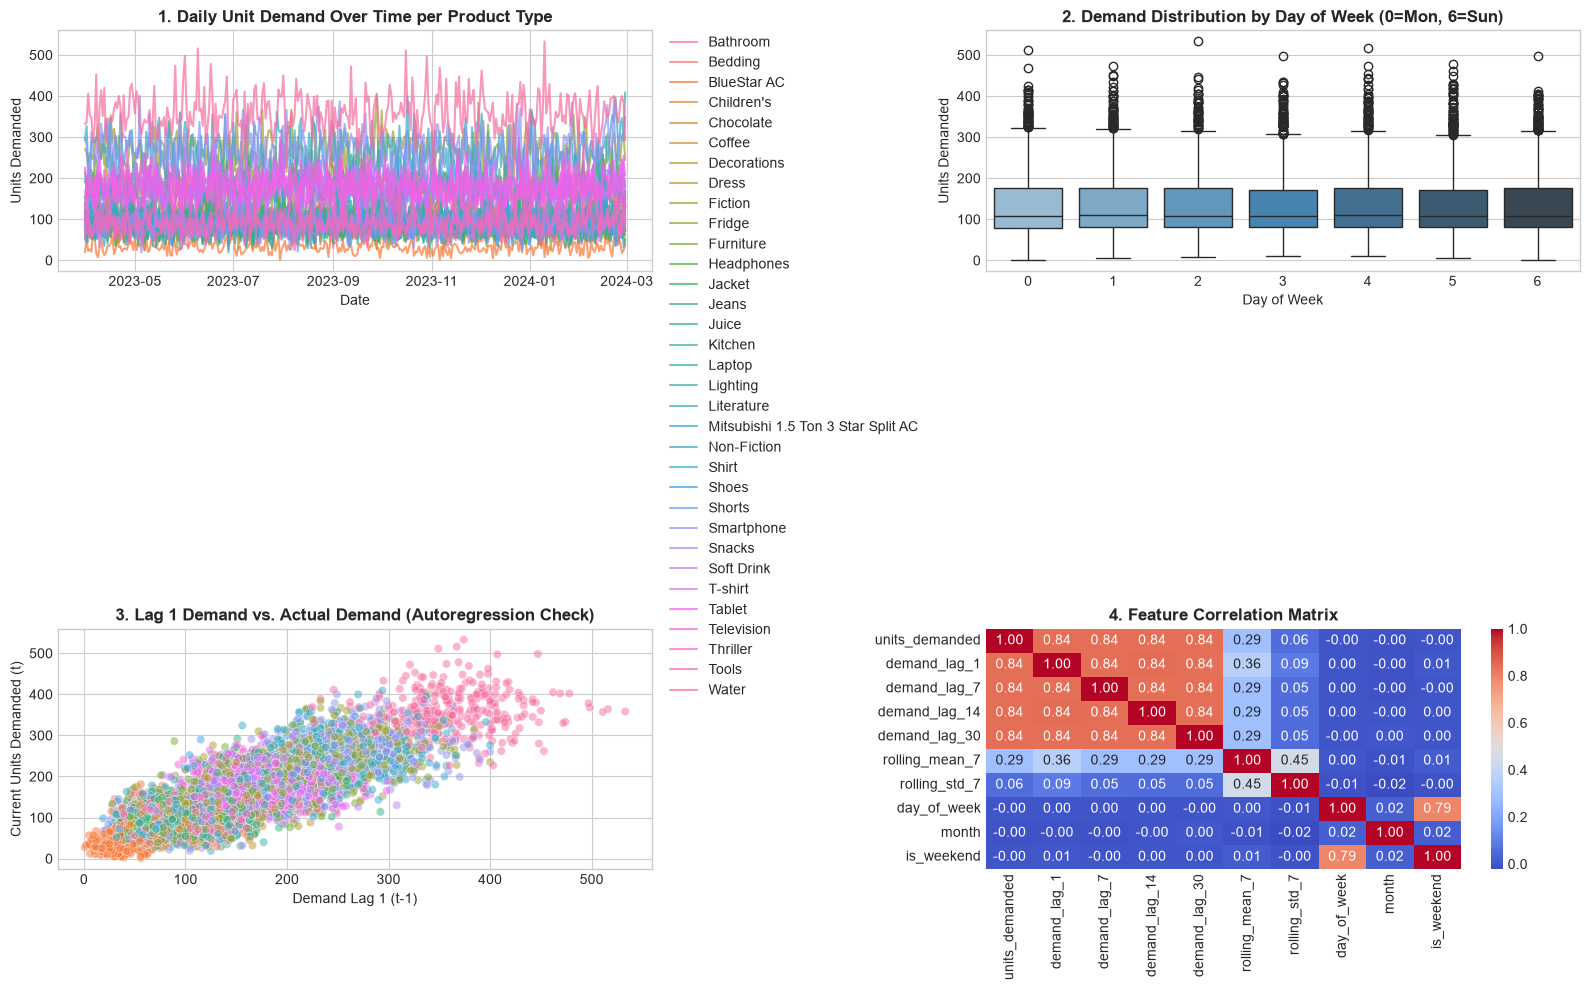

In [ ]:
# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------------------------------------------
# 1. Target Demand Over Time (Check continuity, trends, & outliers)
# -------------------------------------------------------------
sns.lineplot(
    data=product_type_sales_clean,
    x='date',
    y='units_demanded',
    hue='product_type',
    ax=axes[0, 0],
    alpha=0.7
)
axes[0, 0].set_title('1. Daily Unit Demand Over Time per Product Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Units Demanded')
axes[0, 0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# -------------------------------------------------------------
# 2. Seasonality: Day of Week Distribution (Validates calendar features)
# -------------------------------------------------------------
sns.boxplot(
    data=product_type_sales_clean,
    x='day_of_week',
    y='units_demanded',
    ax=axes[0, 1],
    palette='Blues_d'
)
axes[0, 1].set_title('2. Demand Distribution by Day of Week (0=Mon, 6=Sun)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Units Demanded')

# -------------------------------------------------------------
# 3. Autocorrelation: Lag 1 vs Actual Demand (Validates lag signals)
# -------------------------------------------------------------
sns.scatterplot(
    data=product_type_sales_clean,
    x='demand_lag_1',
    y='units_demanded',
    hue='product_type',
    alpha=0.5,
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title('3. Lag 1 Demand vs. Actual Demand (Autoregression Check)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Demand Lag 1 (t-1)')
axes[1, 0].set_ylabel('Current Units Demanded (t)')

# -------------------------------------------------------------
# 4. Feature Correlation Heatmap (Checks multicollinearity & target correlation)
# -------------------------------------------------------------
numeric_cols = [
    'units_demanded', 'demand_lag_1', 'demand_lag_7', 'demand_lag_14',
    'demand_lag_30', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'is_weekend'
]
corr_matrix = product_type_sales_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('4. Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### What We Are Predicting (The ML Objective)

You are solving a **Supervised Time-Series Regression** problem.

* **The Goal:** Predict the total **number of units** that will sell for each `product_type` on any given future day.


* **The Business Purpose:** Tell inventory and procurement managers how many physical items to stock in the warehouse so they avoid stockouts (running out of inventory) and overstocking (tying up capital).



$$\hat{y}_{p, t} = \text{Predicted Units Sold for Product Type } p \text{ on Day } t$$

---

### Understanding the Target ($y$) vs. Features ($X$)

* **Target Variable ($y$):**
* `units_demanded` $\rightarrow$ The continuous numeric quantity you are trying to predict.




* **Features Matrix ($X$):**
* The input signals the model uses to make that prediction:


* **Category Identifier:** `product_type` (e.g., Electronics, Apparel).


* **Past Demand History:** `demand_lag_1`, `demand_lag_7`, `demand_lag_14`, `demand_lag_30` (How many units sold yesterday, 7 days ago, etc.).


* **Trend & Stability Signals:** `rolling_mean_7`, `rolling_std_7` (Recent 7-day velocity and volatility).


* **Calendar & Seasonality Signals:** `day_of_week`, `month`, `is_weekend`.







---

### What to Drop (Avoid Data Leakage & Redundancy)

When defining $X$, do not include:

1. `units_demanded` $\rightarrow$ This is the target $y$ itself.
2. `total_revenue` $\rightarrow$ **Data Leakage!** Revenue is calculated as $\text{Price} \times \text{Units Demanded}$. If you feed revenue into $X$, the model will simply divide revenue by price rather than learning real demand trends.


3. `date` $\rightarrow$ Datetime objects cannot be multiplied by weights directly in regression. Its useful components are already captured in `day_of_week`, `month`, and `is_weekend`.



---

### Step 1: Code to Define Target ($y$) and Features ($X$)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 8843, number of used features: 40
[LightGBM] [Info] Start training from score 133.818048


=== Baseline (Ridge) ===
MAE  : 24.36 units
RMSE : 31.48 units
WAPE : 18.10%

=== LightGBM Regressor ===
MAE  : 25.20 units
RMSE : 32.98 units
WAPE : 18.73%



NameError: name 'baseline_pipe' is not defined